### IRIS Flowers Classification Using Machine Learning

##### Introduction on Classification

在这篇关于鸢尾花分类的文章中，我们将使用逻辑回归机器学习算法。首先，我们将了解逻辑回归，然后我们将理解该算法在鸢尾花数据集上的工作原理。我们都知道鸢尾花数据集，它包含不同花卉品种的特征。该数据集中的自变量特征是萼片长度、萼片宽度、花瓣长度和花瓣宽度。所有这些长度都以厘米为单位。而因变量特征，也就是模型的输出，是物种。它包含具有这些测量值的特定花朵所属的物种名称。

在创建机器学习模型之前，让我们先了解逻辑回归。

#### Decision Tree

#### Working with Dataset

在创建模型并进行训练之前，我们必须对数据集进行预处理。预处理意味着在将数据集用于任何机器学习算法之前，将其转换为可理解的格式。它包括数据转换、数据规约、数据清洗以及更多其他处理。

让我们使用逻辑回归构建一个机器学习模型。为此，我们将采用鸢尾花数据集。

首先，我们加载一些重要的Python Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.simplefilter("ignore")

`matplotlib和seaborn`用于可视化，而`warnings`则用于忽略我们遇到的所有警告。

从本地桌面导入数据集。使用`pandas`来完成这个任务。在`read_csv`方法中输入数据集文件的路径。它将导入鸢尾花数据集。

In [2]:
# Import test and train dataset
test = pd.read_csv('results/gdt_t_test_df.csv', index_col=0)
test.head()

,HES4,ISG15,TNFRSF18,TNFRSF4,MMP23B,NADK,MEGF6,TNFRSF25,TNFRSF9,ERRFI1,...,LDOC1,AFF2,ZNF185,PNMA3,PDZD4,TKTL1,PLXNA3,MPP1,CLIC2,gd_anno
AAACAAGCACATTGTCACTTTAGG-1,0.0,0.0,0.000000,0.0,0.0,0.000000,0.825543,1.813600,0.0,0.0,...,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.0,abt
AAACAAGCACCATACTACTTTAGG-1,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.00000,1.494708,0.0,1.003942,0.0,0.0,abt
AAACAAGCATTTGTTGACTTTAGG-1,0.0,0.0,1.256215,0.0,0.0,0.608334,0.608334,0.983850,0.0,0.0,...,0.983850,0.0,0.0,0.98385,0.000000,0.0,0.000000,0.0,0.0,abt
AAACCAATCAAACCGGACTTTAGG-1,0.0,0.0,0.663697,0.0,0.0,0.000000,0.663697,0.663697,0.0,0.0,...,0.663697,0.0,0.0,0.00000,0.663697,0.0,0.000000,0.0,0.0,abt
AAACCAGGTGATTACCACTTTAGG-1,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,1.328549,0.0,0.0,...,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.0,abt


In [3]:
train = pd.read_csv('results/gdt_t_train_df.csv', index_col=0)
train.head()

,HES4,ISG15,TNFRSF18,TNFRSF4,MMP23B,NADK,MEGF6,TNFRSF25,TNFRSF9,ERRFI1,...,LDOC1,AFF2,ZNF185,PNMA3,PDZD4,TKTL1,PLXNA3,MPP1,CLIC2,gd_anno
AGTAAACGTCCATAGTAGCTGTGA-1,0.0,0.809897,0.0,0.0,0.0,0.000000,0.000000,0.809897,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.809897,0.0,0.0,abt
TCGCGCATCTAGCGGAATCCCAAC-1,0.0,0.000000,0.0,0.0,0.0,0.000000,0.840415,0.840415,0.0,0.000000,...,0.0,0.0,0.0,0.840415,0.0,0.0,0.000000,0.0,0.0,abt
CTTAGCCAGTTATGGAAACGCCGA-1,0.0,1.107442,0.0,0.0,0.0,0.699777,0.699777,1.396222,0.0,0.699777,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.699777,0.0,0.0,abt
CAGGTATAGGACACGCAGCTGTGA-1,0.0,0.000000,0.0,0.0,0.0,0.674481,1.073645,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.674481,0.0,0.0,0.000000,0.0,0.0,abt
TGGGCCACATTTAGCCAACGCCGA-1,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.740785,0.0,0.0,abt


查看数据框的信息，其中包含非空变量的计数以及列的数据类型和列名等详细信息。它还将显示内存使用情况。

In [4]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53011 entries, AAACAAGCACATTGTCACTTTAGG-1 to TTTGTGAGTAGTTGTCATTCGGTT-1
Columns: 2100 entries, HES4 to gd_anno
dtypes: float64(2099), object(1)
memory usage: 849.7+ MB


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, AGTAAACGTCCATAGTAGCTGTGA-1 to TCAGGCTTCGCGGATAACTTTAGG-1
Columns: 2100 entries, HES4 to gd_anno
dtypes: float64(2099), object(1)
memory usage: 32.1+ MB


如果有任何缺失值，那么在使用数据集之前对它们进行修改。对于修改，你可以使用fillna()方法。它将填充空值。

In [6]:
# checking for null values
train.isnull().sum()

HES4        0
ISG15       0
TNFRSF18    0
TNFRSF4     0
MMP23B      0
           ..
TKTL1       0
PLXNA3      0
MPP1        0
CLIC2       0
gd_anno     0
Length: 2100, dtype: int64

In [7]:
test.isnull().sum()

HES4        0
ISG15       0
TNFRSF18    0
TNFRSF4     0
MMP23B      0
           ..
TKTL1       0
PLXNA3      0
MPP1        0
CLIC2       0
gd_anno     0
Length: 2100, dtype: int64

我们可以看到所有值都是0。这意味着整个数据框中没有空值。

要查看数据框中的列名，请使用columns

In [8]:
train.columns

Index(['HES4', 'ISG15', 'TNFRSF18', 'TNFRSF4', 'MMP23B', 'NADK', 'MEGF6',
       'TNFRSF25', 'TNFRSF9', 'ERRFI1',
       ...
       'LDOC1', 'AFF2', 'ZNF185', 'PNMA3', 'PDZD4', 'TKTL1', 'PLXNA3', 'MPP1',
       'CLIC2', 'gd_anno'],
      dtype='object', length=2100)

如果我们查看数据框，我们可以看到有两列具有相同的id编号。要删除不需要的ID列，请使用drop方法。

In [10]:
train['gd_anno'].value_counts()

gd_anno
abt    1000
gdt    1000
Name: count, dtype: int64

定义`x`和`y`。`x`包含所有输入变量，如自变量特征，而`y`应包含因变量，它依赖于自变量，即输出。

In [11]:
from sklearn.linear_model import LogisticRegression  
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix  
import matplotlib.pyplot as plt  
import seaborn as sns

In [12]:
# 分离特征和目标变量  
# 前35列是特征，最后一列是目标变量  
X_train = train.iloc[:, :-1]  # 所有行，除了最后一列  
y_train = train.iloc[:, -1]   # 所有行，只取最后一列  

X_test = test.iloc[:, :-1]    # 所有行，除了最后一列  
y_test = test.iloc[:, -1]     # 所有行，只取最后一列 

In [13]:
# 查看目标变量的类别分布  
print("训练集目标变量分布:")  
print(y_train.value_counts())

训练集目标变量分布:
gd_anno
abt    1000
gdt    1000
Name: count, dtype: int64


In [14]:
# 随机森林  
from sklearn.ensemble import RandomForestClassifier  

In [15]:
rf_model = RandomForestClassifier(  
    n_estimators=100,  
    max_depth=None,  
    min_samples_split=2,  
    random_state=42,  
    class_weight='balanced'  
)

In [16]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [17]:
y_pred_rf = rf_model.predict(X_test)

In [18]:
# 评估模型性能  
accuracy = accuracy_score(y_test, y_pred_rf)  
print(f"\n模型准确率: {accuracy:.4f}")


模型准确率: 0.9881


In [19]:
# 打印详细的分类报告  
print("\n分类报告:")  
print(classification_report(y_test, y_pred_rf))


分类报告:
              precision    recall  f1-score   support

         abt       1.00      0.99      0.99     52447
         gdt       0.47      1.00      0.64       564

    accuracy                           0.99     53011
   macro avg       0.74      0.99      0.82     53011
weighted avg       0.99      0.99      0.99     53011



In [20]:
# 创建结果DataFrame  
results_df = pd.DataFrame({  
    'cell_id': X_test.index,  # 使用测试数据的索引作为cell_id  
    'cell_type': y_pred_rf       # 使用模型预测的细胞类型  
}) 

In [21]:
results_df.head(10)

,cell_id,cell_type
0,AAACAAGCACATTGTCACTTTAGG-1,abt
1,AAACAAGCACCATACTACTTTAGG-1,abt
2,AAACAAGCATTTGTTGACTTTAGG-1,abt
3,AAACCAATCAAACCGGACTTTAGG-1,abt
4,AAACCAGGTGATTACCACTTTAGG-1,abt
5,AAACCAGGTGGTTATCACTTTAGG-1,abt
6,AAACCAGGTTAAGGCAACTTTAGG-1,abt
7,AAACGGGCAACCCTATACTTTAGG-1,abt
8,AAACGGGCAATACTGGACTTTAGG-1,abt
9,AAACGGGCAATCGTTCACTTTAGG-1,abt


In [22]:
# 假设y_test是真实标签，y_pred_voting是投票分类器的预测结果  
# 将标签转换为字符串类型  
y_true_str = [str(label) for label in y_test]  
y_pred_str = [str(label) for label in y_pred_rf] 

In [23]:
# 获取所有唯一的类别标签  
unique_true_labels = np.unique(y_true_str)  
unique_pred_labels = np.unique(y_pred_str)  
all_classes = sorted(list(set(list(unique_true_labels) + list(unique_pred_labels))))  

# 计算混淆矩阵  
cm = confusion_matrix(y_true_str, y_pred_str, labels=all_classes)

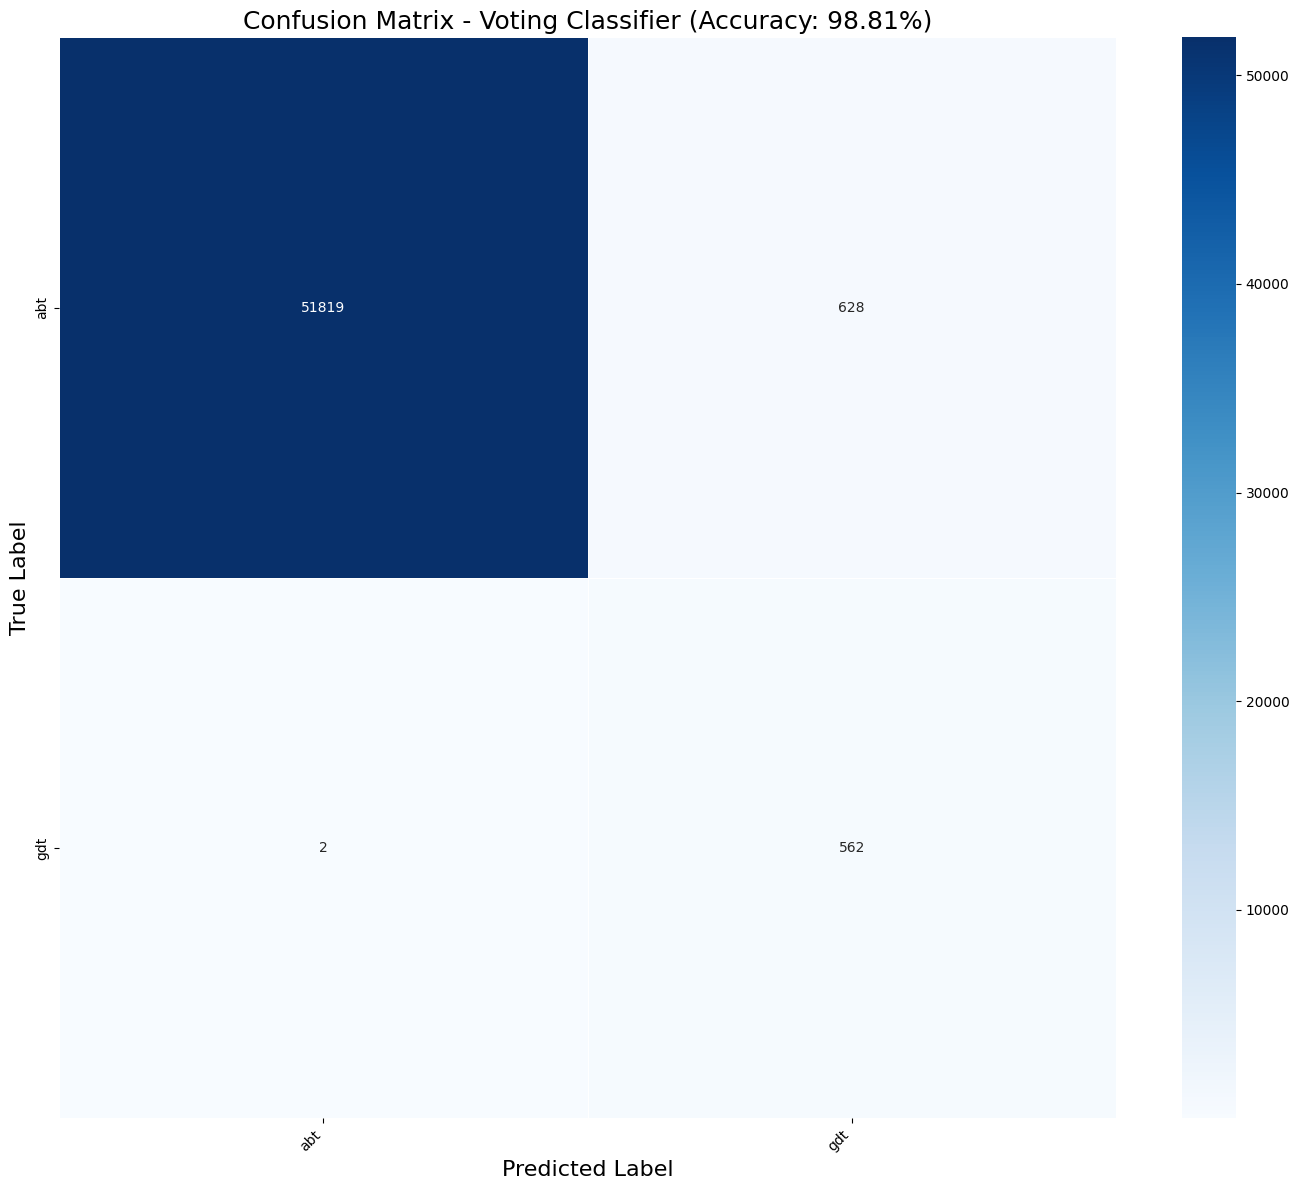

In [24]:
# 创建DataFrame以便于使用seaborn绘图  
cm_df = pd.DataFrame(cm, index=all_classes, columns=all_classes)  

# 设置图形大小  
plt.figure(figsize=(14, 12))  

# 使用seaborn绘制热图  
heatmap = sns.heatmap(cm_df, annot=True, fmt='d', cmap="Blues", linewidths=.5)  

# 添加标题和标签  
plt.title(f'Confusion Matrix - Voting Classifier (Accuracy: {accuracy*100:.2f}%)', fontsize=18)  
plt.ylabel('True Label', fontsize=16)  
plt.xlabel('Predicted Label', fontsize=16)  
plt.xticks(fontsize=10, rotation=45, ha='right')  
plt.yticks(fontsize=10)  

# 调整布局以确保标签完全可见  
plt.tight_layout()  

# 显示图形  
plt.show()

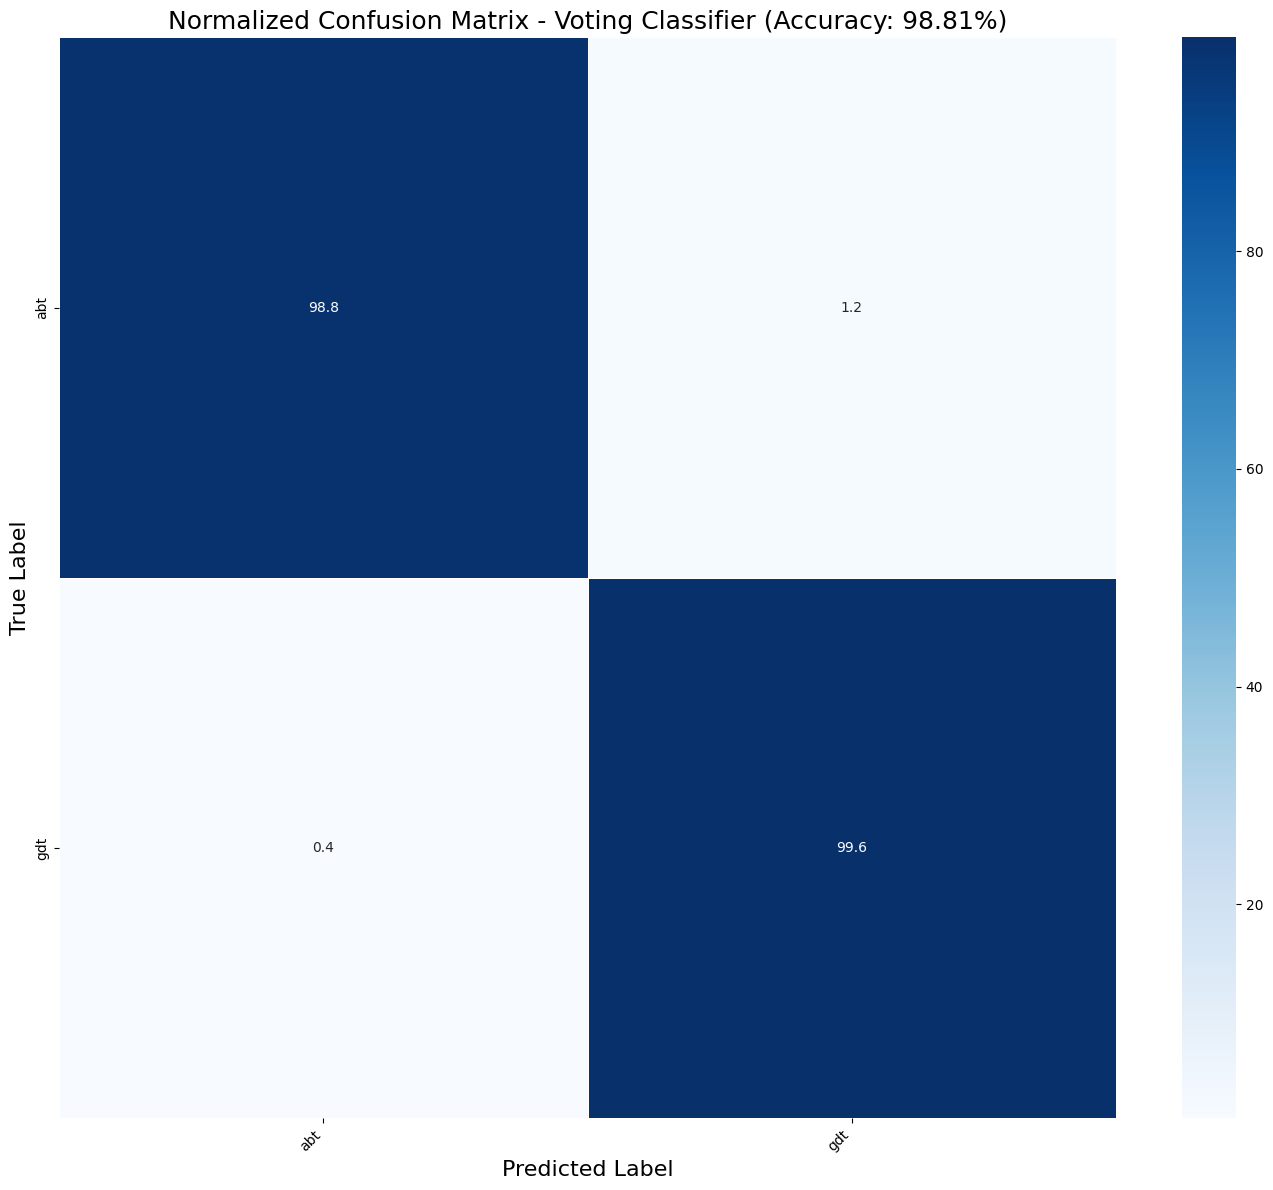

In [25]:
# 计算并绘制百分比混淆矩阵（按行归一化）  
row_sums = cm.sum(axis=1)  
# 避免除以零  
row_sums_safe = np.maximum(row_sums, 1)  # 将零替换为1以避免除以零  
cm_percent = (cm.astype('float') / row_sums_safe[:, np.newaxis]) * 100  
cm_percent_df = pd.DataFrame(cm_percent, index=all_classes, columns=all_classes)  

plt.figure(figsize=(14, 12))  
sns.heatmap(cm_percent_df, annot=True, fmt='.1f', cmap="Blues", linewidths=.5)  
plt.title(f'Normalized Confusion Matrix - Voting Classifier (Accuracy: {accuracy*100:.2f}%)', fontsize=18)  
plt.ylabel('True Label', fontsize=16)  
plt.xlabel('Predicted Label', fontsize=16)  
plt.xticks(fontsize=10, rotation=45, ha='right')  
plt.yticks(fontsize=10)  
plt.tight_layout()  
plt.show()


Accuracy by Class:
abt: 0.9880 (98.80%) - count: 52447
gdt: 0.9965 (99.65%) - count: 564


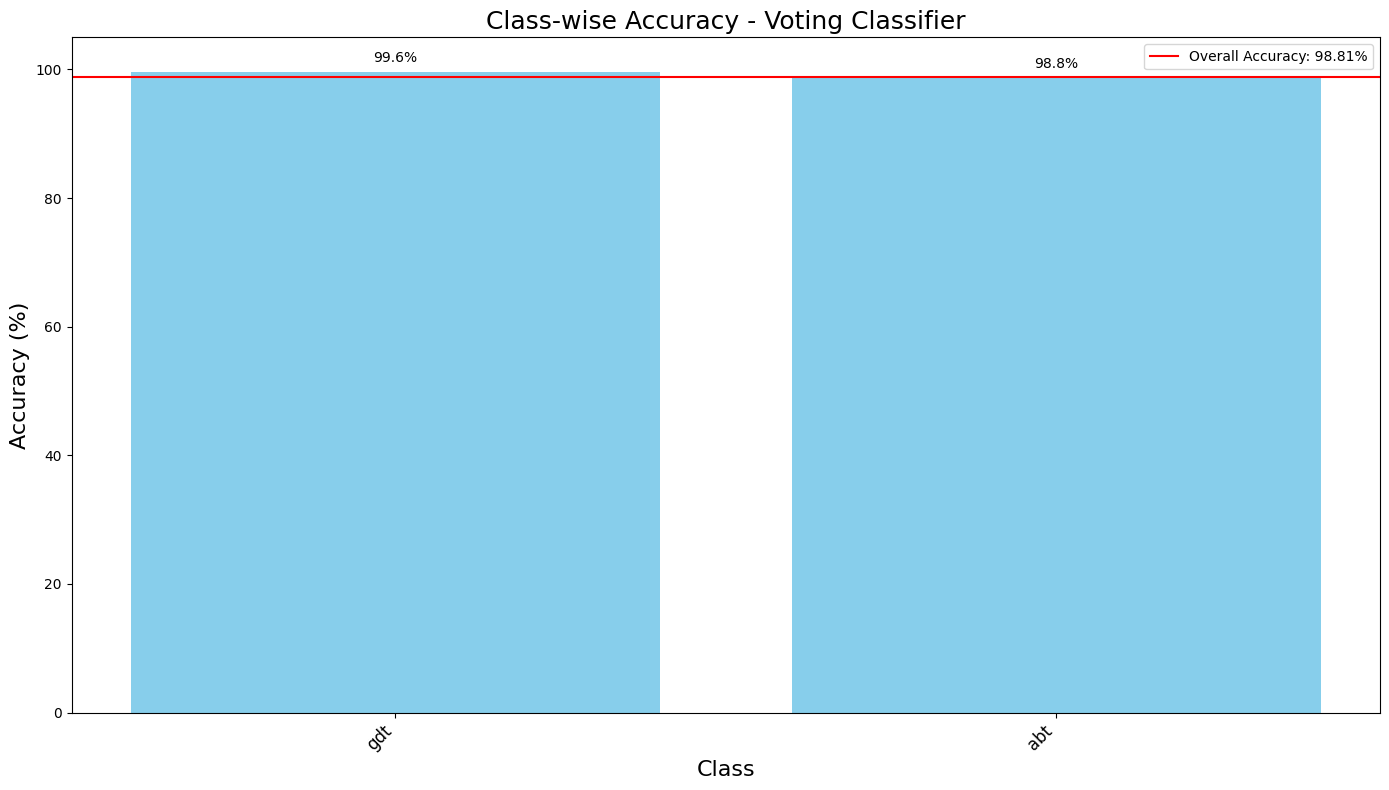

In [26]:
# 计算每个类别的准确率（对角线元素/行总和）  
class_accuracies = {}  
class_counts = {}  
for i, class_name in enumerate(all_classes):  
    total_samples = row_sums[i]  
    correct_predictions = cm[i, i]  
    class_counts[class_name] = total_samples  
    
    if total_samples > 0:  # 避免除以零  
        class_acc = correct_predictions / total_samples  
    else:  
        class_acc = np.nan  # 使用NaN表示没有样本的类别  
    
    class_accuracies[class_name] = class_acc  

# 显示每个类别的准确率和样本数  
print("\nAccuracy by Class:")  
for class_name, acc in class_accuracies.items():  
    count = class_counts[class_name]  
    if np.isnan(acc):  
        print(f"{class_name}: No samples (count: {count})")  
    else:  
        print(f"{class_name}: {acc:.4f} ({acc*100:.2f}%) - count: {count}")  

# 创建并显示每个类别准确率的条形图（仅包含有样本的类别）  
valid_classes = [cls for cls in all_classes if class_counts[cls] > 0]  
valid_accs = [class_accuracies[cls] for cls in valid_classes]  
valid_counts = [class_counts[cls] for cls in valid_classes]  

# 创建排序索引（根据准确率从高到低）  
if valid_classes:  
    sorted_indices = np.argsort(valid_accs)[::-1]  
    sorted_classes = [valid_classes[i] for i in sorted_indices]  
    sorted_accs = [valid_accs[i] for i in sorted_indices]  
    sorted_counts = [valid_counts[i] for i in sorted_indices]  

    plt.figure(figsize=(14, 8))  
    bars = plt.bar(sorted_classes, [acc*100 for acc in sorted_accs], color='skyblue')  
    plt.axhline(y=accuracy*100, color='r', linestyle='-', label=f'Overall Accuracy: {accuracy*100:.2f}%')  

    plt.title('Class-wise Accuracy - Voting Classifier', fontsize=18)  
    plt.xlabel('Class', fontsize=16)  
    plt.ylabel('Accuracy (%)', fontsize=16)  
    plt.xticks(rotation=45, ha='right', fontsize=12)  
    plt.ylim(0, 105)  # 设置y轴范围从0到105%  
    
    # 在条形顶部添加准确率标签  
    for bar in bars:  
        height = bar.get_height()  
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,  
                f'{height:.1f}%', ha='center', va='bottom', rotation=0)  

    plt.legend()  
    plt.tight_layout()  
    plt.show()


Accuracy by Class:
abt: 0.9880 (98.80%)
gdt: 0.9965 (99.65%)


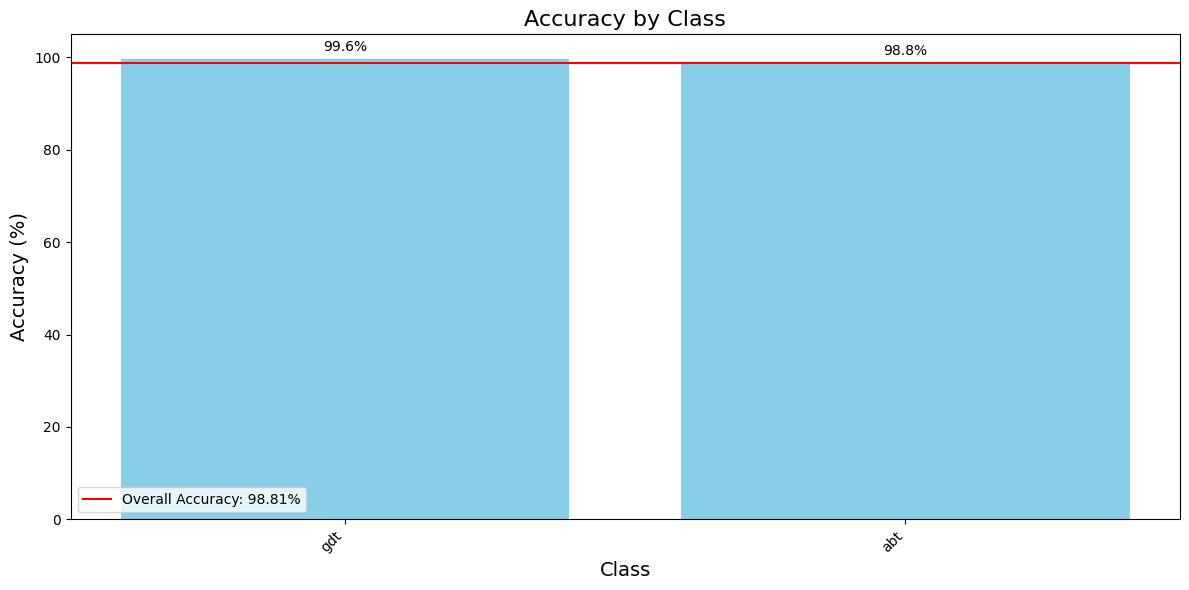

In [27]:
# 计算每个类别的准确率（对角线元素/行总和）  
class_accuracies = {}  
for i, class_name in enumerate(all_classes):  
    if row_sums[i] > 0:  # 避免除以零  
        class_acc = cm[i, i] / row_sums[i]  
        class_accuracies[class_name] = class_acc  

# 显示每个类别的准确率  
print("\nAccuracy by Class:")  
for class_name, acc in class_accuracies.items():  
    print(f"{class_name}: {acc:.4f} ({acc*100:.2f}%)")  

# 可选：创建并显示每个类别准确率的条形图  
plt.figure(figsize=(12, 6))  
classes = list(class_accuracies.keys())  
accs = [class_accuracies[cls] for cls in classes]  

# 排序类别和准确率（从高到低）  
sorted_indices = np.argsort(accs)[::-1]  
sorted_classes = [classes[i] for i in sorted_indices]  
sorted_accs = [accs[i] for i in sorted_indices]  

bars = plt.bar(sorted_classes, [acc*100 for acc in sorted_accs], color='skyblue')  
plt.axhline(y=accuracy*100, color='r', linestyle='-', label=f'Overall Accuracy: {accuracy*100:.2f}%')  

plt.title('Accuracy by Class', fontsize=16)  
plt.xlabel('Class', fontsize=14)  
plt.ylabel('Accuracy (%)', fontsize=14)  
plt.xticks(rotation=45, ha='right')  
plt.ylim(0, 105)  # 设置y轴范围从0到105%  

# 在条形顶部添加准确率标签  
for bar in bars:  
    height = bar.get_height()  
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,  
             f'{height:.1f}%', ha='center', va='bottom', rotation=0)  

plt.legend()  
plt.tight_layout()  
plt.show()  

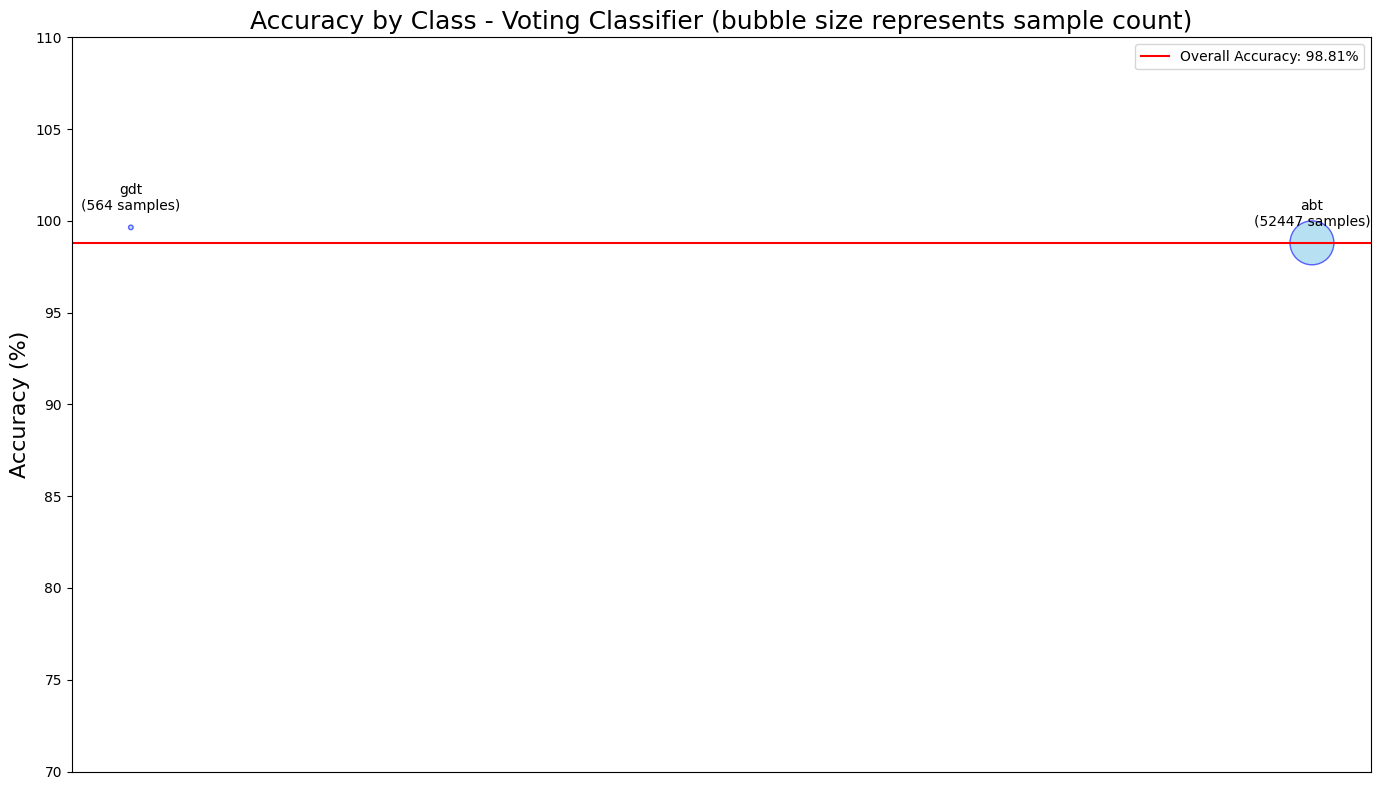

In [28]:
    # 另一种可视化：气泡图 - 同时显示准确率和样本数  
    plt.figure(figsize=(14, 8))  
    
    # 创建气泡图，大小表示样本数  
    sizes = [count/max(sorted_counts)*1000 for count in sorted_counts]  # 归一化大小  
    
    plt.scatter(range(len(sorted_classes)), [acc*100 for acc in sorted_accs],   
               s=sizes, alpha=0.6, c='skyblue', edgecolors='blue')  
    
    plt.axhline(y=accuracy*100, color='r', linestyle='-', label=f'Overall Accuracy: {accuracy*100:.2f}%')  
    
    # 添加标签  
    for i, cls in enumerate(sorted_classes):  
        plt.annotate(f"{cls}\n({sorted_counts[i]} samples)",   
                    (i, sorted_accs[i]*100),  
                    xytext=(0, 10),   
                    textcoords='offset points',  
                    ha='center', va='bottom')  
    
    plt.xticks([])  # 隐藏x轴刻度  
    plt.title('Accuracy by Class - Voting Classifier (bubble size represents sample count)', fontsize=18)  
    plt.ylabel('Accuracy (%)', fontsize=16)  
    plt.ylim(70, 110)  
    plt.legend()  
    plt.tight_layout()  
    plt.show()